# Chemotaxis

**Dr. Panagiotis Sakagiannis, Dr. Alexandros Marantis**

## About this notebook

Give a larva an odor it likes and it will find the source. How it does so is the interesting part :
it has no way of measuring the direction of a gradient at a single instant. It has one olfactory
sensor at the front of its body, and it moves that sensor from side to side while crawling. The
concentration change it experiences during a head sweep tells it whether the sweep was in a good
direction, and biases the next turn accordingly. This is **active sensing**, and in the model it
consists of exactly one thing : the sensed concentration change modulates the turner oscillator,
while the crawler is left alone.

Two stored experiments put that mechanism in two different situations, and they are the two
conditions of the classic study by Gomez-Marin, Stephens & Louis (2011) :

| | where the odor is | where the larvae are | what should happen |
|---|---|---|---|
| **Experiment 1** (`chemotaxis`) | on the right of a rectangular arena | on the left, facing right | they climb the gradient and approach |
| **Experiment 2** (`chemorbit`) | in the centre | in the centre | they explore locally, crossing and re-crossing |

Both experiments already exist. As in the rest of this section, we only choose how many larvae take
part.

**What you will be able to do afterwards**

- Run the same model in two odor landscapes and see two different behaviors emerge.
- Read the odor concentration each virtual larva actually experienced over time.
- Follow the chain from sensed concentration to turning : `c_odor1` → `dc_odor1` → `A_olf` → `A_T`.
- Say what these simulations do and do not demonstrate.

**Prerequisites** : [Free exploration](free_exploration.ipynb). The locomotion is the same; only the
sensor is new.

**Cost** : two simulations, a few minutes each.

**Switches in this notebook**

| switch | default | what it turns on |
|---|---|---|
| `RUN_SIMULATION` | `True` | both experiments, and therefore every figure below |
| `SAVE_VIDEO` | `False` | a third run that renders one of them to a video file |

## Setup

Both experiments are named here, since this notebook runs two of them.

In [1]:
%matplotlib inline

import matplotlib

import larvaworld
from larvaworld.lib import reg
from larvaworld.lib.sim.single_run import ExpRun

# The timeplots below draw thousands of points per line; letting matplotlib
# simplify the paths keeps the rendered figures small without changing them.
matplotlib.rcParams["path.simplify"] = True
matplotlib.rcParams["path.simplify_threshold"] = 1.0

larvaworld.VERBOSE = 1

# Tutorial safety switches
RUN_SIMULATION = True  # the point of this notebook; a few minutes of compute
SAVE_VIDEO = False  # re-run with rendering and write a video file

APPROACH = "chemotaxis"  # experiment 1 : source far away, larvae facing it
LOCAL = "chemorbit"  # experiment 2 : source and larvae both at the centre
N = 20  # larvae; the stored experiments' duration and timestep are left untouched

MEDIA_DIR = "./media/simulated_experiments"
plot_dir = f"{MEDIA_DIR}/chemotaxis"

Initializing larvaworld registry


Registry configured!


## Section 1 : The two experiments

The arena is the same in both - a 100 x 60 mm rectangle - and so is the model. What differs is where
the odor source sits, how strong it is, and where the animals are released.

In [2]:
def describe(expID):
    conf = reg.conf.Exp.getID(expID)
    env = conf.env_params
    print(
        f"{expID} : {conf.duration} min at dt={conf.dt} s, "
        f"arena {[round(x * 1000) for x in env.arena.dims]} mm, "
        f"{env.odorscape.odorscape} odorscape"
    )
    for sid, s in env.food_params.source_units.items():
        print(
            f"   source {sid!r} at {[round(v * 1000, 1) for v in s.pos]} mm : "
            f"odor {s.odor.id!r}, intensity {s.odor.intensity}, spread {s.odor.spread:.3f}"
        )
    for gid, g in conf.larva_groups.items():
        dis = g.distribution
        print(
            f"   group  {gid!r} : model {g.model}, released around "
            f"{[round(v * 1000) for v in dis.loc]} mm, orientations {dis.orientation_range}"
        )
    print()


describe(APPROACH)
describe(LOCAL)

chemotaxis : 5.0 min at dt=0.1 s, arena [100, 60] mm, Gaussian odorscape
   source 'Source' at [40.0, 0.0] mm : odor 'Odor', intensity 4.0, spread 0.014
   group  'navigator' : model navigator, released around [-40, 0] mm, orientations (-30.0, 30.0)

chemorbit : 5.0 min at dt=0.1 s, arena [100, 60] mm, Gaussian odorscape
   source 'Source' at [0.0, 0.0] mm : odor 'Odor', intensity 2.0, spread 0.010
   group  'navigator' : model navigator, released around [0, 0] mm, orientations (0.0, 360.0)



Note the orientations. In experiment 1 the larvae start facing the source, within ±30° — the
experiment asks whether they can *climb* a gradient, not whether they can find one by luck. In
experiment 2 they start at the source with any orientation, and the question is what they do once
they are already there.

The sensor that makes the difference is the olfactor module, which the `explorer` model of the
previous notebooks does not have at all.

In [3]:
navigator = reg.conf.Model.getID("navigator").brain
explorer = reg.conf.Model.getID("explorer").brain

print(f"{'module':16s} {'explorer':12s} navigator")
for k in navigator.keylist:

    def mode(b):
        v = b[k]
        return v.mode if isinstance(v, dict) and "mode" in v else "-"

    print(f"{k:16s} {mode(explorer):12s} {mode(navigator)}")

module           explorer     navigator
crawler          realistic    realistic
interference     phasic       phasic
turner           neural       neural
intermitter      default      default
feeder           -            -
olfactor         -            default
toucher          -            -
windsensor       -            -
thermosensor     -            -
memory           -            -
nengo            -            -


## Section 2 : Experiment 1 - approaching the source

Larvae on the left, odor on the right. They should end up near it.

In [4]:
d_app = None
r_app = ExpRun(experiment=APPROACH, N=N)
if RUN_SIMULATION:
    r_app.simulate()
    d_app = r_app.datasets[0]
    print(f"{d_app.id} : {d_app.config.N} larvae, stored at {d_app.dir}")
else:
    print("Set RUN_SIMULATION = True to run the experiments.")

--- Simulation chemotaxis_10 initialized!--- 
--- Simulation chemotaxis_10 : Generating agent groups!--- 



Run time: 0:01:01.949772
Simulation finished
--- Simulation chemotaxis_10 completed in 62 seconds!--- 
--- Enriching dataset navigator ---
Vector orientations are already computed. If you want to recompute them, set recompute to True


Angular analysis complete.
Spatial analysis complete.


Bearing and distance to source computed
--- Dataset navigator enriched ---
--------------------------------


***** Dataset navigator stored.-----
Simulation chemotaxis_10 stored in directory C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemotaxis/chemotaxis_10


navigator : 20 larvae, stored at C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemotaxis/chemotaxis_10/data/navigator


Larvaworld knows which figures belong to a chemotaxis experiment. `analyze()` looks the experiment
up, runs the plots registered for it, writes them next to the datasets and returns them grouped by
topic - the trajectories, the chemosensation timeseries, and the locomotion measured relative to the
odor source.

In [5]:
def show(run, group=None):
    """Display the figures a finished run's analysis produced."""
    if not RUN_SIMULATION:
        return
    groups = run.figs if group is None else {group: run.figs[group]}
    for gname, figs in groups.items():
        for name, fig in figs.items():
            print(f"[{gname}] {name}")
            display(fig)

In [6]:
if RUN_SIMULATION:
    r_app.analyze()
    print("Figure groups :", {g: list(f) for g, f in r_app.figs.items()})

Plot comparative_trajectories_default.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemotaxis/chemotaxis_10/plots/traj\comparative_trajectories_default.pdf


Plot aligned2origin.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemotaxis/chemotaxis_10/plots/traj\aligned2origin.pdf
Fitted pooled epoch durations.
Plot runsNpauses.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemotaxis/chemotaxis_10/plots/general\runsNpauses.pdf


Plot chemosensation.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemotaxis/chemotaxis_10/plots/chemo\chemosensation.pdf
Plot bearing_to_Object.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemotaxis/chemotaxis_10/plots/locomotion_relative_to_source_Object\bearing_to_Object.pdf


Plot dst_to_Object.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemotaxis/chemotaxis_10/plots/locomotion_relative_to_source_Object\dst_to_Object.pdf
Plot scaled_dst_to_Object.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemotaxis/chemotaxis_10/plots/locomotion_relative_to_source_Object\scaled_dst_to_Object.pdf
Figure groups : {'traj': ['trajectories', 'aligned2origin'], 'general': ['epochs'], 'chemo': ['chemosensation'], 'locomotion_relative_to_source_Object': ['bearing_to_Object', 'dst_to_Object', 'scaled_dst_to_Object']}


### The paths

The tracks should run left to right and crowd near the source. They are not straight : a larva
climbing a gradient still crawls in strides and still pauses to cast its head, and the approach is
the statistical result of many small turning decisions rather than a steering command.

[traj] trajectories


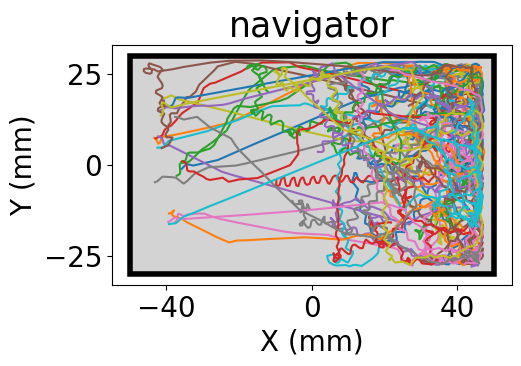

[traj] aligned2origin


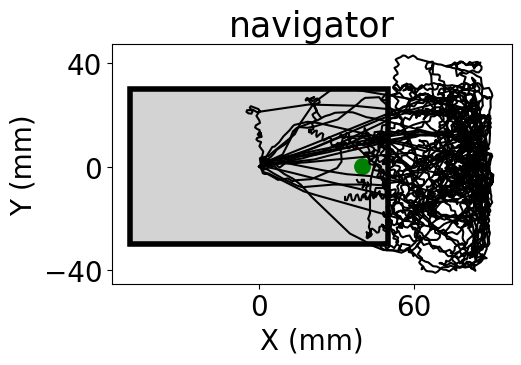

In [7]:
show(r_app, "traj")

### What the larva sensed

This is the group that shows the mechanism rather than its result. Five quantities over time,
averaged across the population :

| key | what it is |
|---|---|
| `c_odor1` | the odor concentration at the larva's sensor |
| `dc_odor1` | how fast that concentration is changing |
| `A_olf` | the olfactory activation derived from it |
| `A_T` | the resulting input to the turner |
| `I_T` | the turner's own tonic input |

`c_odor1` rising over time *is* the approach, expressed in the only variable the animal has access
to.

[chemo] chemosensation


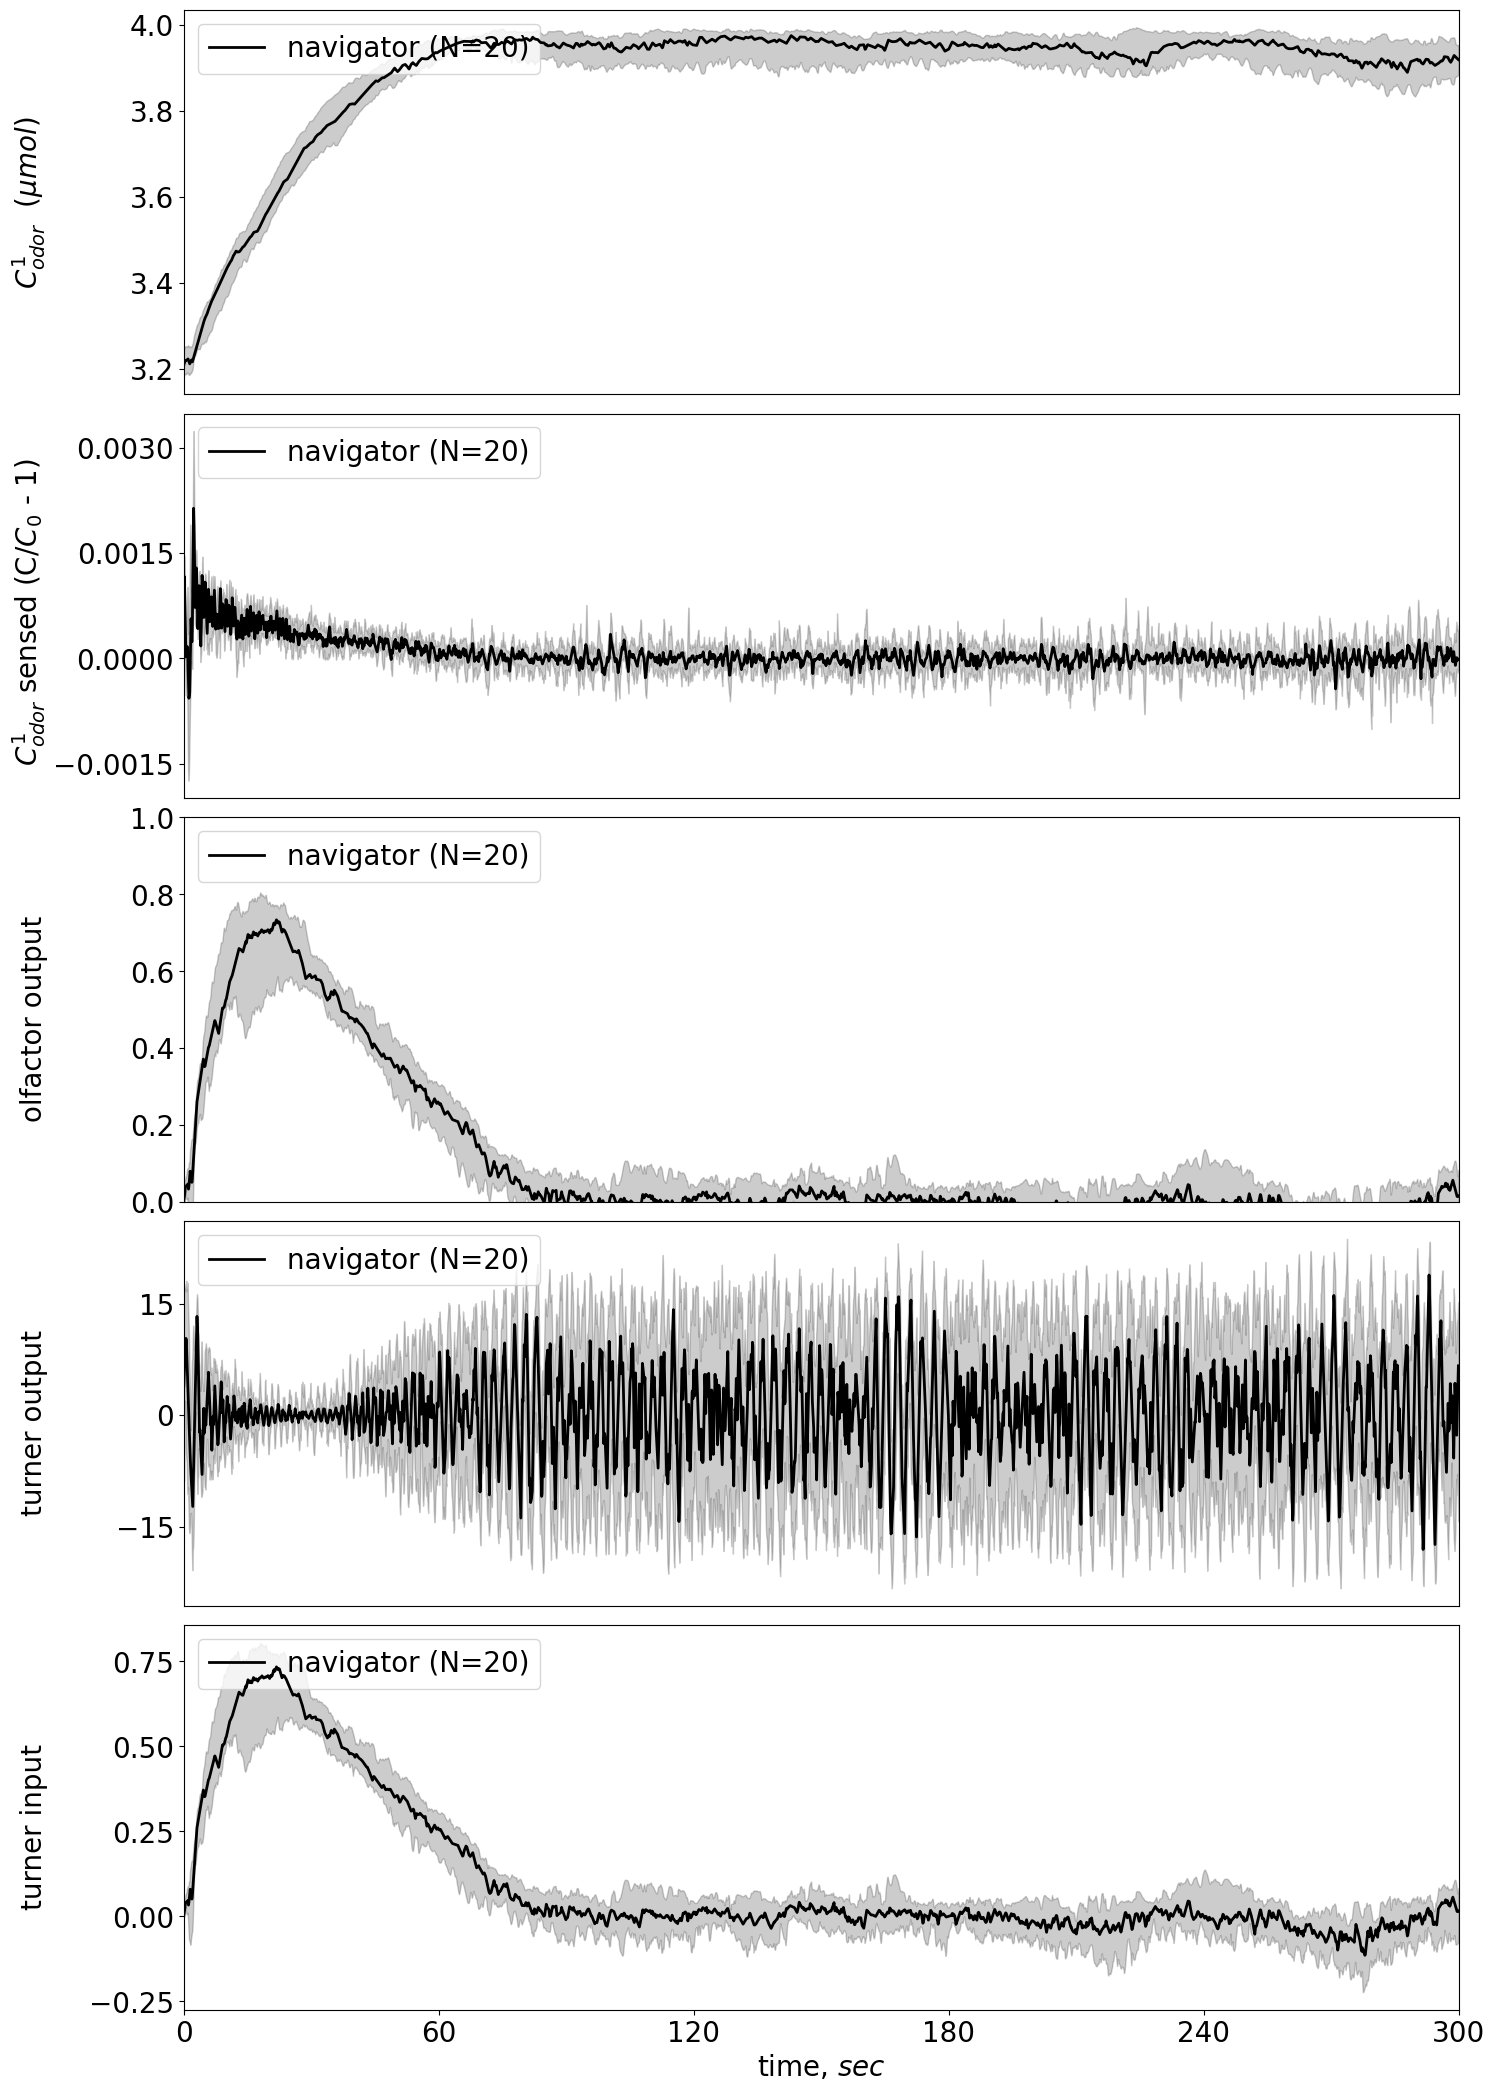

In [8]:
show(r_app, "chemo")

### Locomotion relative to the source

Because the experiment declares an odor source, the analysis adds a group measured against it :
the bearing to the source, the distance to it, and that distance scaled by body length. The distance
falling over time is the approach stated in the plainest possible terms.

[locomotion_relative_to_source_Object] bearing_to_Object


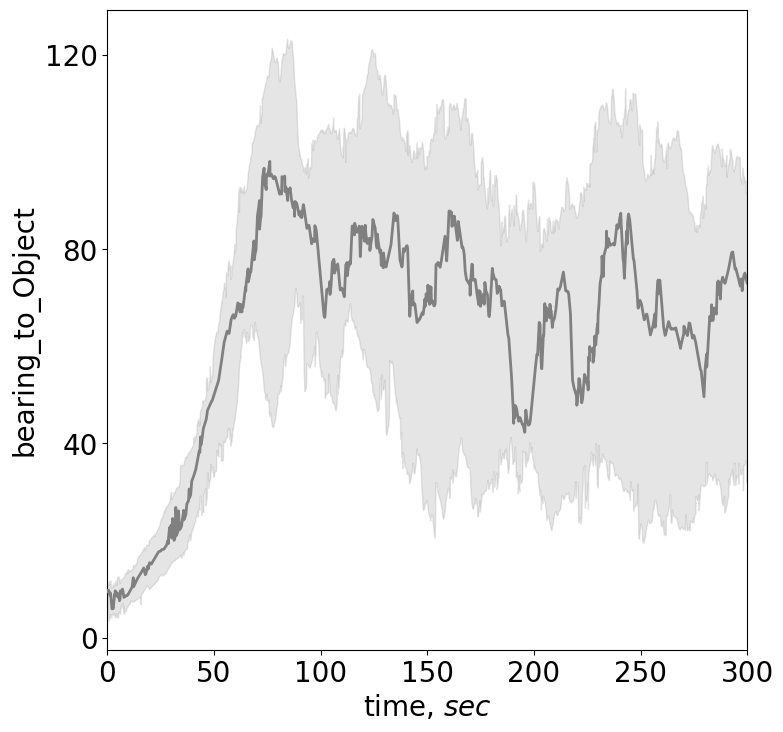

[locomotion_relative_to_source_Object] dst_to_Object


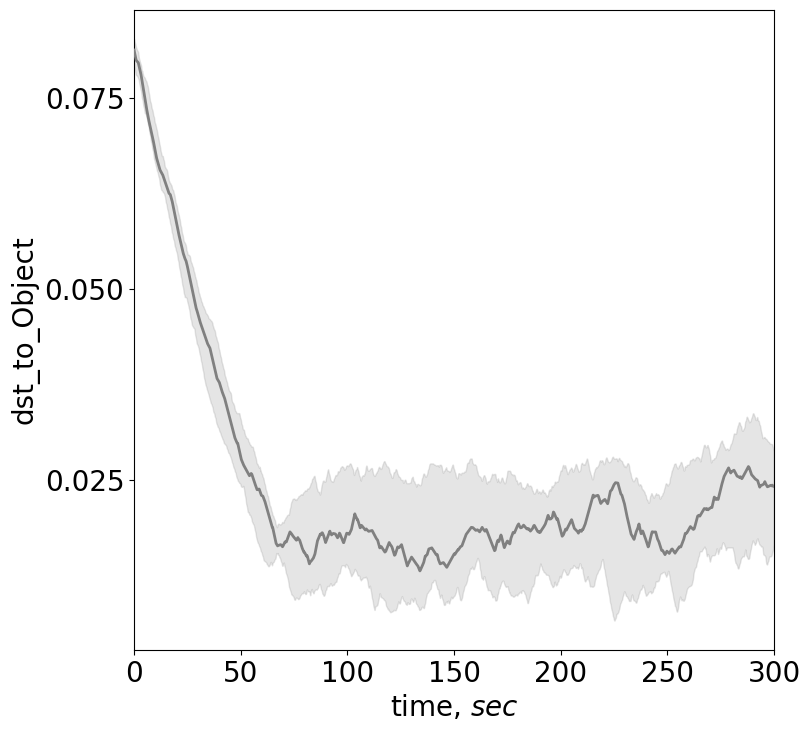

[locomotion_relative_to_source_Object] scaled_dst_to_Object


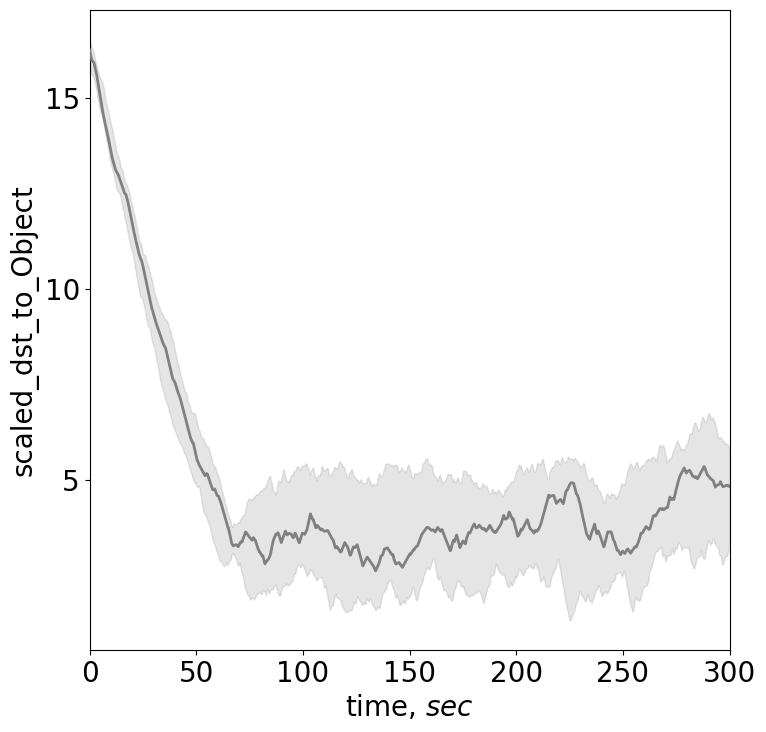

In [9]:
show(r_app, "locomotion_relative_to_source_Object")

## Section 3 : Experiment 2 - staying at the source

Same arena, same model, weaker source, and now everything starts in the middle. There is no gradient
to climb, because the animals begin at its peak.

In [10]:
d_loc = None
r_loc = ExpRun(experiment=LOCAL, N=N)
if RUN_SIMULATION:
    r_loc.simulate()
    d_loc = r_loc.datasets[0]
    print(f"{d_loc.id} : {d_loc.config.N} larvae, stored at {d_loc.dir}")

--- Simulation chemorbit_34 initialized!--- 
--- Simulation chemorbit_34 : Generating agent groups!--- 



Run time: 0:01:04.672371
Simulation finished
--- Simulation chemorbit_34 completed in 65 seconds!--- 
--- Enriching dataset navigator ---
Vector orientations are already computed. If you want to recompute them, set recompute to True


Angular analysis complete.
Spatial analysis complete.


Bearing and distance to source computed
--- Dataset navigator enriched ---
--------------------------------


***** Dataset navigator stored.-----
Simulation chemorbit_34 stored in directory C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_34


navigator : 20 larvae, stored at C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_34/data/navigator


In [11]:
if RUN_SIMULATION:
    r_loc.analyze()
    print("Figure groups :", {g: list(f) for g, f in r_loc.figs.items()})

Plot comparative_trajectories_default.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_34/plots/traj\comparative_trajectories_default.pdf


Plot aligned2origin.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_34/plots/traj\aligned2origin.pdf
Fitted pooled epoch durations.
Plot runsNpauses.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_34/plots/general\runsNpauses.pdf


Plot chemosensation.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_34/plots/chemo\chemosensation.pdf
Plot bearing_to_Object.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_34/plots/locomotion_relative_to_source_Object\bearing_to_Object.pdf


Plot dst_to_Object.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_34/plots/locomotion_relative_to_source_Object\dst_to_Object.pdf
Plot scaled_dst_to_Object.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/chemorbit/chemorbit_34/plots/locomotion_relative_to_source_Object\scaled_dst_to_Object.pdf
Figure groups : {'traj': ['trajectories', 'aligned2origin'], 'general': ['epochs'], 'chemo': ['chemosensation'], 'locomotion_relative_to_source_Object': ['bearing_to_Object', 'dst_to_Object', 'scaled_dst_to_Object']}


The expected picture is a dense tangle around the centre : larvae leave the source, sense the
concentration dropping, turn back, and cross it again. The same active-sensing rule that produced a
directed approach in experiment 1 produces localized exploration here, with no change to the model —
only the odor landscape and the starting position differ.

[traj] trajectories


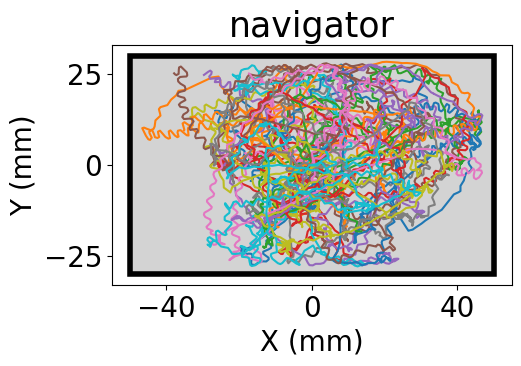

[traj] aligned2origin


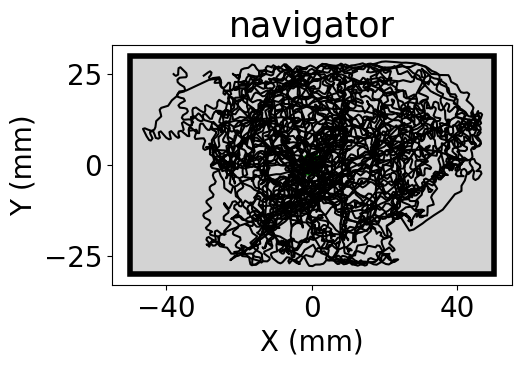

In [12]:
show(r_loc, "traj")

[chemo] chemosensation


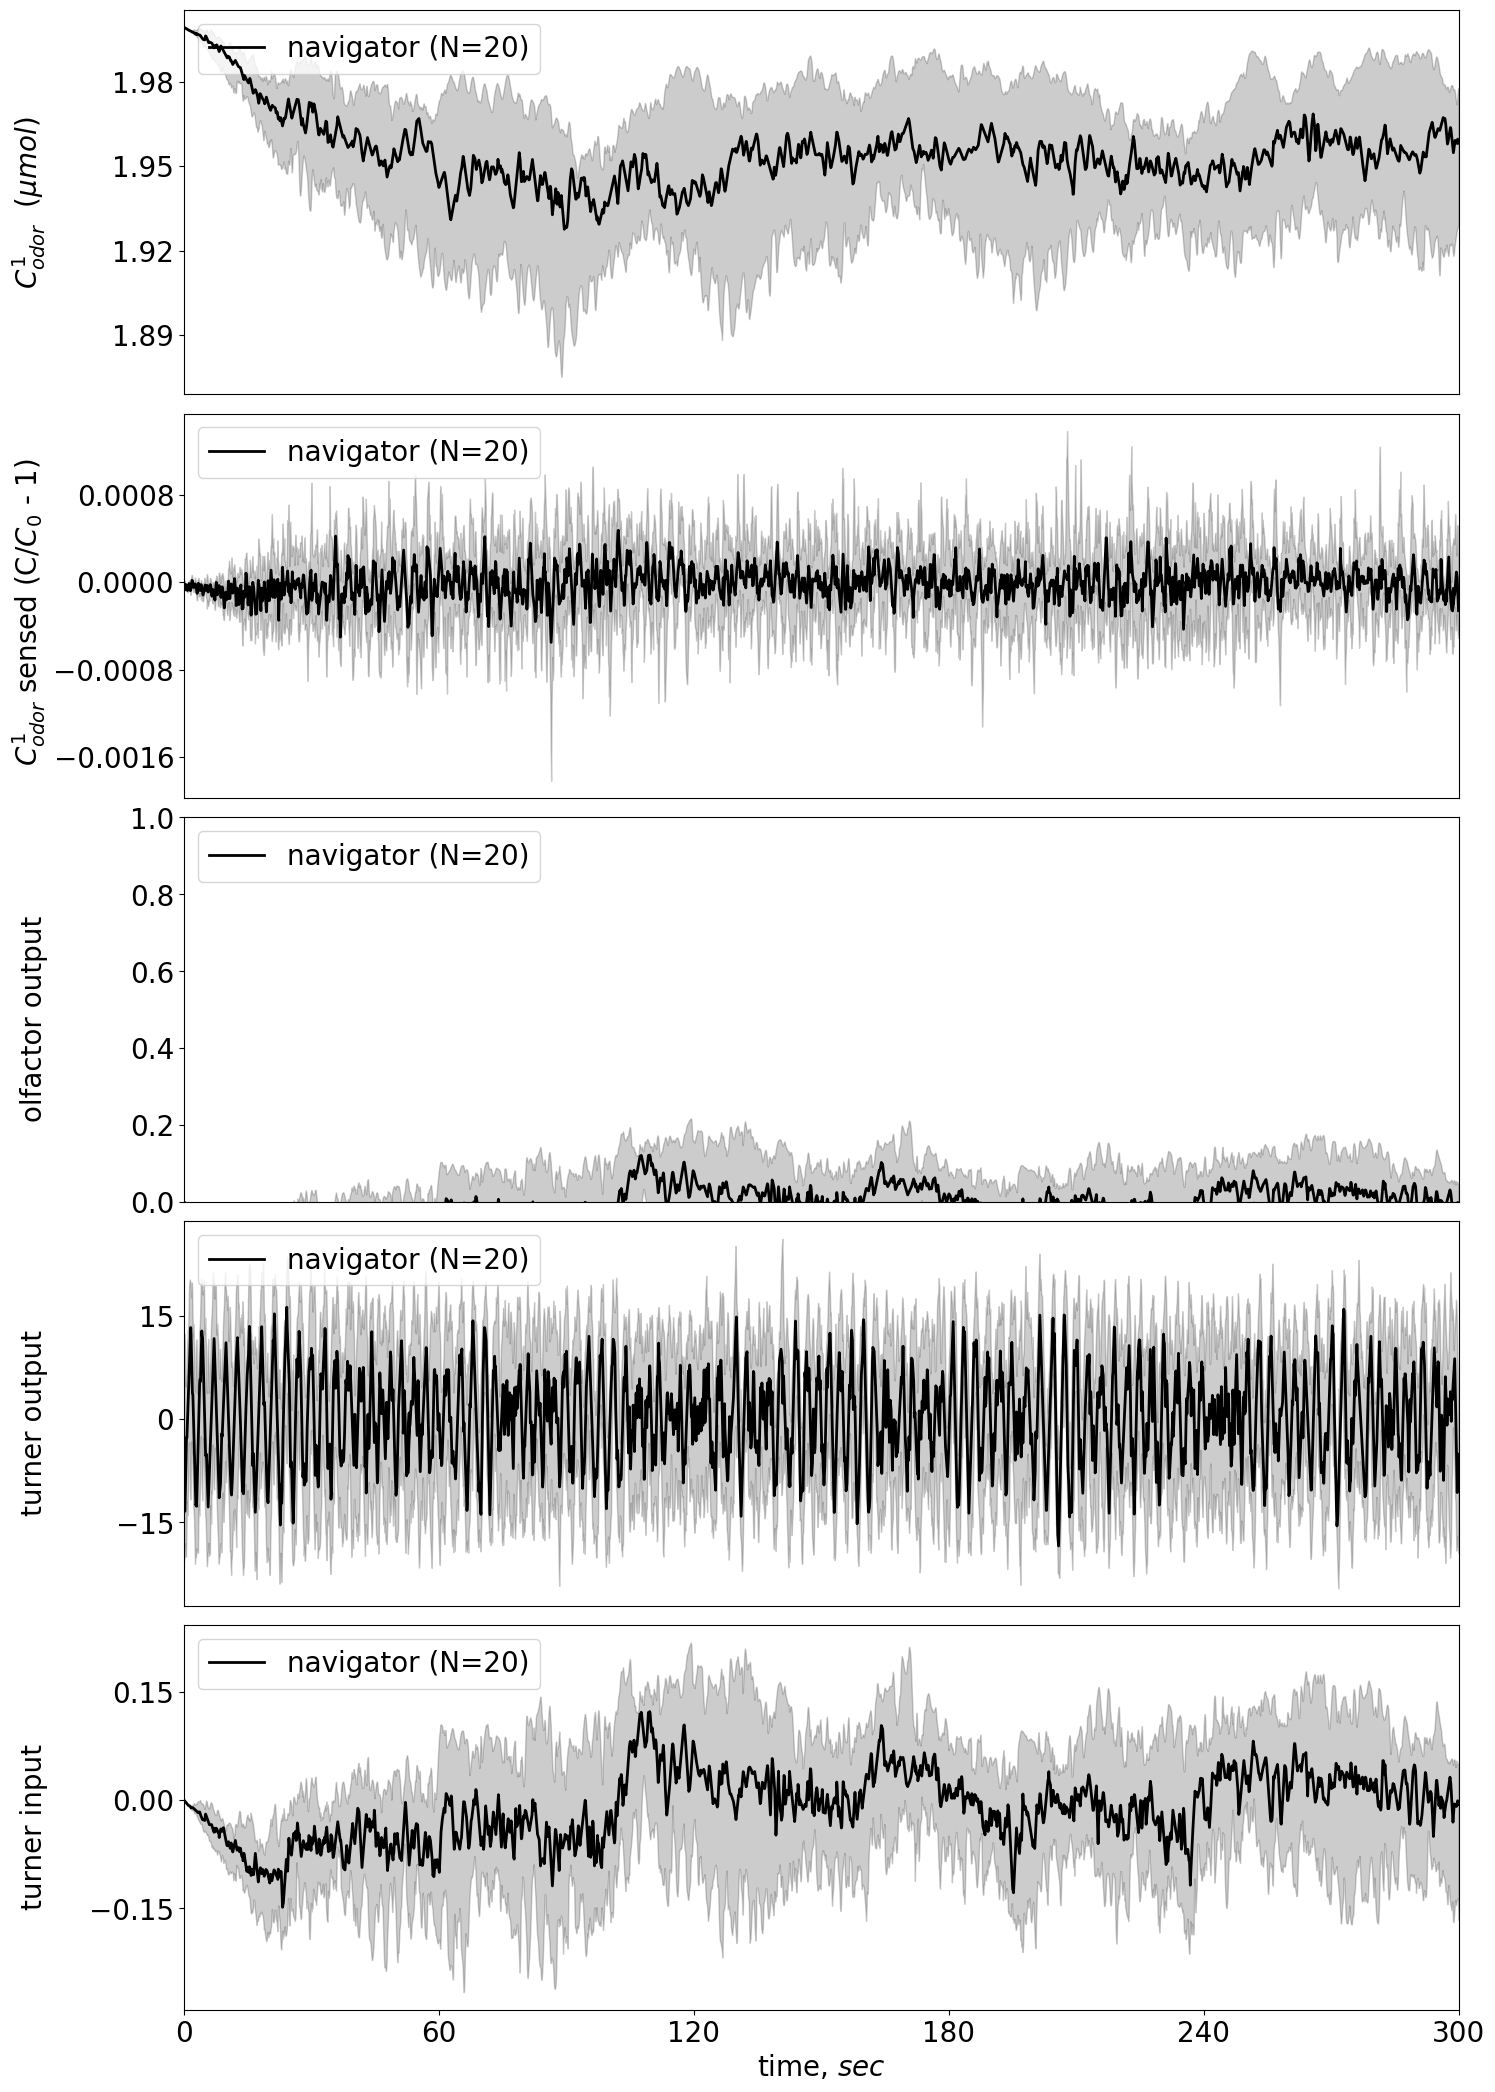

In [13]:
show(r_loc, "chemo")

[locomotion_relative_to_source_Object] bearing_to_Object


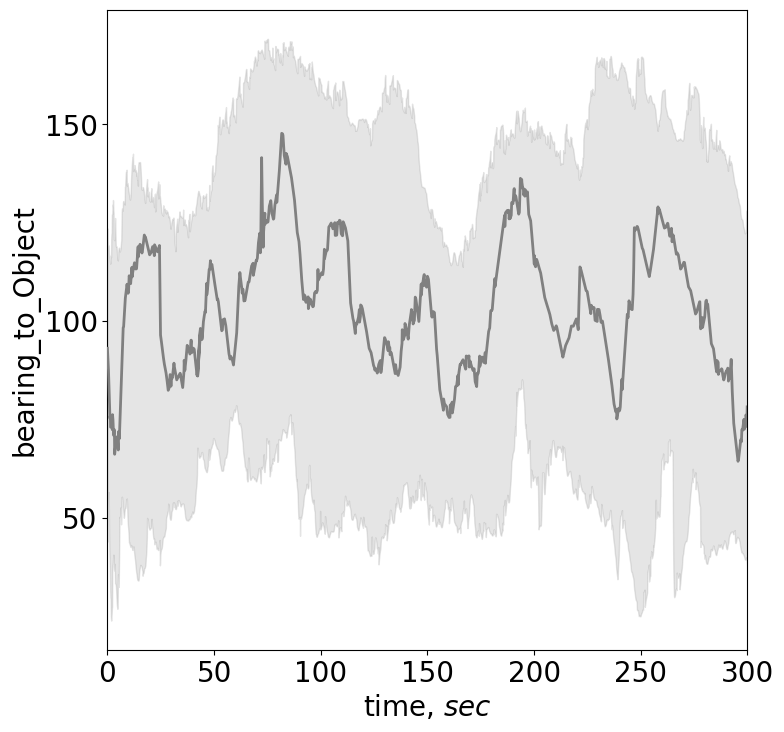

[locomotion_relative_to_source_Object] dst_to_Object


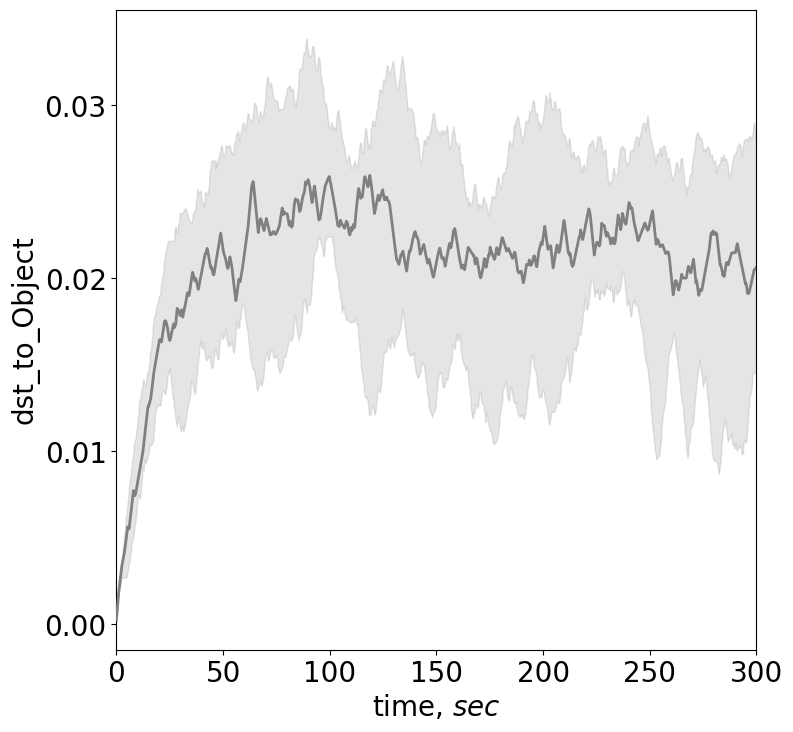

[locomotion_relative_to_source_Object] scaled_dst_to_Object


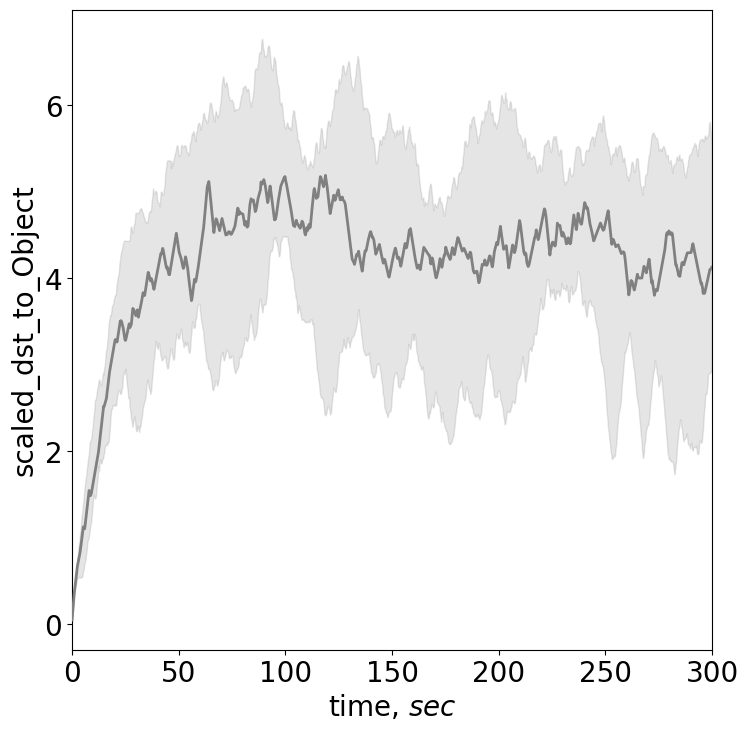

In [14]:
show(r_loc, "locomotion_relative_to_source_Object")

Compare this concentration trace with the one from experiment 1. There, `c_odor1` climbed and
stayed high. Here it fluctuates around a level, because the animals keep leaving the peak and
returning to it - which is the behavioral signature of the second condition.

### Rendering one of them

Both experiments can be watched rather than only measured.

In [15]:
if SAVE_VIDEO:
    r_vid = ExpRun(
        experiment=LOCAL,
        N=N,
        screen_kws={
            "vis_mode": "video",
            "show_display": False,
            "save_video": True,
            "media_dir": MEDIA_DIR,
            "video_file": "chemotaxis_local",
            "odor_aura": True,
            "visible_trails": True,
        },
    )
    r_vid.simulate()
    print(f"Video written to {MEDIA_DIR}/chemotaxis_local.mp4")
else:
    print("Set SAVE_VIDEO = True to render one of the experiments to a video file.")

Set SAVE_VIDEO = True to render one of the experiments to a video file.


## What the paper reports

This is Figure 5 of Sakagiannis et al. (2025), and both experiments are reconstructions of
Gomez-Marin et al. (2011) : the arena and odor landscape of that study's Figure 1C for the approach,
and of its Figure 1D for the local case.

**The mechanism.** The odor sensor modulates the turner oscillator and nothing else - its frequency
and amplitude - while the crawler runs unchanged. That single pathway, following Wystrach et al.
(2016), is the whole of navigation in this architecture. In the layered view of the
[theoretical background](../1_getting_started/theoretical_background.ipynb), it is the *reactive*
layer modulating the *motor* layer through one channel.

**What was and was not fitted.** Every parameter of the motor layer - crawling, lateral bending,
crawl-bend interference, intermittency - was fitted on free-exploration data alone, and then kept
fixed for these simulations. Nothing here was tuned to make chemotaxis work.

**What these simulations claim.** The paper is explicit : the chemotaxis results are a
*proof-of-concept* qualitative reproduction of the behavioral patterns, not a quantitatively
calibrated model. It deliberately does not report success rates, approach distances or track-length
statistics, because those depend strongly on the specific odorscape geometry. The right way to read
the figures above is as *the mechanism produces the right kind of behavior in both conditions*, not
as a measurement of how well it does so.

## Where to go next

- [Odor preference](odor_preference.ipynb) - two odors instead of one, and a population-level score.
- [Sensory landscapes](../4_models_and_environments/sensory_landscapes.ipynb) - how the odorscape
  under these experiments is defined.
- [Custom brain modules](../6_extending_larvaworld/custom_brain_modules.ipynb) - replacing the
  olfactor with your own.
- Reference : [Brain module architecture](../../agents_environments/brain_module_architecture.md).

## References

> Sakagiannis PP, Jürgensen AM, Nawrot MP. 2025. *A behavioral architecture for realistic
simulations of Drosophila larva locomotion and foraging.* eLife 14:RP104262.
<https://doi.org/10.7554/eLife.104262>

> Gomez-Marin A, Stephens GJ, Louis M. 2011. *Active sampling and decision making in Drosophila
chemotaxis.* Nature Communications 2:410-441. <https://doi.org/10.1038/ncomms1455>

> Wystrach A, Lagogiannis K, Webb B. 2016. *Continuous lateral oscillations as a core mechanism
for taxis in Drosophila larvae.* eLife 5:e15504. <https://doi.org/10.7554/eLife.15504>

> Sakagiannis PP, Rapp H, Jovanic T, Nawrot MP. 2025. *Larvaworld: a behavioral simulation and
analysis platform for Drosophila larva.* bioRxiv.
<https://doi.org/10.1101/2025.06.15.659765>